# Emerging Technologies Problems Notebook

This assignment explores the Deutsch–Jozsa algorithm, one of the earliest and most instructive examples of a quantum algorithm that outperforms any classical equivalent. The problem is deceptively simple: given a Boolean function that is guaranteed to be either constant or balanced, determine which one it is. Classically, answering this with certainty requires evaluating the function on just over half of all possible inputs — an exponential number of calls as the input size grows. The Deutsch–Jozsa algorithm answers the same question with a single query, regardless of how many input bits the function takes.

The assignment builds towards this result incrementally across five problems. Problem 1 establishes the mathematical setting by implementing a generator for random constant and balanced functions over four Boolean inputs — the functions the algorithm will ultimately be tested on. Problem 2 then tackles the problem classically, making the computational cost of the brute-force approach concrete and giving a baseline to compare against. Problems 3 and 4 introduce the quantum machinery, starting with the single-input case: Problem 3 constructs the four quantum oracles needed to represent every possible single-bit Boolean function, and Problem 4 implements Deutsch's algorithm — the simplest instance of the general approach — demonstrating how superposition and interference can extract a global property of a function from a single evaluation. Problem 5 then brings everything together, generalising the circuit to four input qubits and running it against the functions generated in Problem 1, with the classical solver from Problem 2 used to verify the quantum result at each step.

In [1]:
# imports used in this notebook

import numpy as np
import random
from itertools import product
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import qiskit_aer as aer
from IPython.display import display
import matplotlib

## Problem 1: Generating Random Boolean Functions

### **Introduction**

Before we can test any algorithm, we need something to test it on. This first problem sets up the playground: a way to randomly generate the kinds of functions that Deutsch–Jozsa is designed to classify.

***What kind of functions are we dealing with?***
The type of function that the Deutsch and Deutsch–Jozsa algorithms are meant to classify is known as a Boolean function. As described in the official Python documentation, a [Boolean function](https://docs.python.org/3/c-api/bool.html) takes one or more binary inputs and returns a single binary output. The inputs and outputs can only ever be one of two values — in mathematics and circuit diagrams these are written as **1** and **0**, while in Python they are written as **True** and **False**.

These two notations mean exactly the same thing.

For a function with a **single** Boolean input, there are exactly four possible functions:

| Function | f(0) | f(1) | f(False) | f(True) | Type |
|:---:|:---:|:---:|:---:|:---:|:---:|
| f₁ | 0 | 0 | False | False | Constant |
| f₂ | 1 | 1 | True | True | Constant |
| f₃ | 0 | 1 | False | True | Balanced |
| f₄ | 1 | 0 | True | False | Balanced |


For this notebook, we're working with functions that take four Boolean inputs — call them a, b, c, d — and return one Boolean value.
With four inputs, there are 2⁴ = 16 possible input combinations, ranging from (False, False, False, False) all the way to (True, True, True, True).

The Deutsch and Deutsch–Jozsa algorithms are built around a guarantee: the function you're given is promised to be one of two types:

* Constant — it returns the same value (always True, or always False) no matter what inputs you give it.
* Balanced — it returns True for exactly half the inputs (8 out of 16) and False for the other half.

The algorithm determines whether the given function is constant or balanced. A constant function maps all inputs to 0 or 1, and a balanced function maps half of its inputs to 0 and the other half to 1. There's no in-between and the algorithm's job is to figure out which type it is.

### **random_constant_balanced() function:**

The function random_constant_balanced acts as a function factory: each time it is called, it randomly constructs and returns one of these promised functions (constant or balanced). Here is the logic in plain terms:

* **Step 1** — constant or balanced: It uses random.choice() to randomly decide whether to make a constant or a balanced function (50/50 chance either way). The random module provides uniform selection of a random element from a sequence, as described in the [Python documentation](https://docs.python.org/3/library/random.html#random.choice)
* **Step 2a** — If constant: It picks a fixed output value (True or False) at random, then returns a function that always outputs that value, completely ignoring its inputs.
* **Step 2b** — If balanced: It lists all 16 possible input combinations using [itertools.product()](https://docs.python.org/3/library/itertools.html#itertools.product). To compute the product of an iterable with itself, you specify the number of repetitions with the optional repeat keyword argument — for example, product(A, repeat=4) means the same as product(A, A, A, A). It then uses [random.sample()](https://docs.python.org/3/library/random.html#random.sample) to pick exactly 8 of those 16 combinations to be the "True" inputs. The result is stored as a Python set for fast lookup, and the function checks whether its input belongs to that set.

Why a set and not a list? Membership testing — checking whether a value is in a collection — has very different performance depending on the data structure. According to the [Python Wiki on Time Complexity](https://wiki.python.org/python/TimeComplexity.html), set membership testing runs in O(1) average time, meaning it's equally fast regardless of how many items the set contains. A list, by contrast, requires scanning through every element, making it slower as the list grows. Since our function may be called many times, the set is the right choice here.

**A note on closures:** Both inner functions (constant_function and balanced_function) rely on a Python feature called a closure — a nested function that retains access to variables defined in its enclosing scope. You can read more about how Python handles this in the Python language reference on naming and binding. This is what allows value or true_inputs to be "baked in" at the time the function is created, so the returned function remembers its configuration even after random_constant_balanced has finished running.

In [2]:
def random_constant_balanced():
    """
    Generate and return a random Boolean function of four inputs that satisfies
    the Deutsch-Jozsa promise.

    Returns:
        function: A callable f(a, b, c, d) -> bool, which is either constant or balanced.
    """
    # Decide whether function is constant or balanced
    is_constant = random.choice([True, False])
    
    # constant case: all outputs are the same (either all True or all False)
    if is_constant:
        # Randomly select the fixed output value the function will always return (will be either True or False)
        value = random.choice([True, False])
        
        # Define the constant inner function - accepts all four Boolean inputs
        def f(a, b, c, d):
            # ignores inputs & returns the same pre-selected value
            return value
        # Return the constant function itself (not its result) so the caller receives a callable they can query with any inputs
        return f
    
    # balanced case: exactly half of the outputs are True and half are False
    else:        
        # Generate all 16 input combinations
        inputs = list(product([False, True], repeat=4))
        
        # Randomly choose 8 combinations to return True
        true_inputs = set(random.sample(inputs, 8))
        
        # Define the balanced inner function - accepts all four Boolean inputs and checks if the combination is in the set of true_inputs to determine its output
        def f(a, b, c, d):
            # checks whether the tuple is one of the 8 selected 'True' inputs using the membership test (in) 
            # returns True if the tuple is in true_inputs and False otherwise.
            return (a, b, c, d) in true_inputs
        # Return the balanced function itself (not its result) so the caller receives a callable they can query with any inputs
        return f

### **Problem 1 Testing**

**Tests for random_constant_balanced()**

**Test:** Show the output of a randomly generated function across all 16 inputs. 

This test calls random_constant_balanced() once to generate a random function then queries it with every possible combination of four Boolean inputs.The results are printed as a truth table, and the function type (constant or balanced) is determined by counting how many outputs are True.

**Note:** Re-run this cell to see a different randomly generated function. You should see a mix of constant and balanced functions appear over multiple runs, with roughly equal probability of each type.

In [3]:
# =============================================================================
# Tests for random_constant_balanced()
# =============================================================================

# Test: Show the output of a randomly generated function across all 16 inputs

print("=" * 40)
print("Test: Output table for a random function")
print("=" * 40)

# Generate a single random function — either constant or balanced
f = random_constant_balanced()

# Print the truth table header
print(f"{'a':>2} {'b':>2} {'c':>2} {'d':>2}  ->  output")
print("-" * 28)

# Query the function with all 16 possible input combinations and record outputs
outputs = []
for a, b, c, d in product([0, 1], repeat=4):
    # Call the function with the current input combination
    out = f(a, b, c, d)
    # Store the output for later analysis
    outputs.append(out)
    # Print the input combination and its corresponding output as 0 or 1
    print(f"{a:>2} {b:>2} {c:>2} {d:>2}  ->  {int(out)}")

# Count how many outputs were True (i.e. 1)
true_count = sum(outputs)

# Determine function type:
# - Constant: all 16 outputs are the same (true_count is 0 or 16)
# - Balanced: exactly 8 outputs are True and 8 are False (true_count is 8)
function_type = "constant" if true_count in (0, 16) else "balanced"

print(f"\nTrue outputs: {true_count}/16  ->  Function is {function_type}\n")

Test: Output table for a random function
 a  b  c  d  ->  output
----------------------------
 0  0  0  0  ->  1
 0  0  0  1  ->  1
 0  0  1  0  ->  1
 0  0  1  1  ->  1
 0  1  0  0  ->  1
 0  1  0  1  ->  1
 0  1  1  0  ->  1
 0  1  1  1  ->  1
 1  0  0  0  ->  1
 1  0  0  1  ->  1
 1  0  1  0  ->  1
 1  0  1  1  ->  1
 1  1  0  0  ->  1
 1  1  0  1  ->  1
 1  1  1  0  ->  1
 1  1  1  1  ->  1

True outputs: 16/16  ->  Function is constant



## **Problem 2: Classical Testing for Function Type**

### **Introduction**

Now that we can generate random constant or balanced functions, the next step is to
write a **classical** solution that can determine which type a given function is. This
is important because it gives us a baseline to compare against — understanding the
classical cost of solving this problem is exactly what motivates the quantum approach.

**What does "classical" mean here?**

[A classical solution](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) can only query the function **one input at a time**. There is no
superposition, no interference — just straightforward calls to `f(a, b, c, d)` and
comparing the results. This is how any ordinary computer program would approach the
problem, and it is the standard against which quantum algorithms are measured.

The key insight is this: you do not always need to check all 16 inputs. If you query
the function twice and get **different outputs**, you already know it must be balanced as a constant function can never return two different values. The worst case is when the
function keeps returning the same output, forcing you to keep querying until you can be
certain.

**How many queries are needed?**

In the worst case, you need **9 queries** to be 100% certain. Here is why:

- If you have seen the same output for the first 8 queries, the function could still be
  balanced — there exist balanced functions that return the same value for up to 8
  consecutive inputs.
- Only when the **9th query** returns the same value can you be certain the function is
  constant, because a balanced function returns `True` for exactly 8 of the 16 inputs
  and cannot return the same value more than 8 times.
- If at any point two queries return **different values**, you can immediately stop and
  conclude the function is balanced.

| Scenario | Queries needed |
|:---|:---:|
| Best case (two different outputs seen immediately) | 2 |
| Worst case (must be certain the function is constant) | 9 |

This worst case of 9 classical queries is exactly what the
[Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
reduces to a **single quantum query** — and that is the quantum advantage.

### **determine_constant_balanced() function**

The function `determine_constant_balanced` takes a function `f` (as generated by
`random_constant_balanced`) and returns the string `"constant"` or `"balanced"`
depending on the result of its analysis.

It works by querying `f` across all 16 possible input combinations and counting how many times it returns `True`. The logic follows directly from the definitions of constant and balanced functions:

- If `f` returns `True` for **all 16 inputs** or `False` for **all 16 inputs** → the output never changes, so the function must be **constant**.
- If `f` returns `True` for **exactly 8 inputs** and `False` for the other 8 → the function must be **balanced**.

Since the Deutsch–Jozsa promise guarantees the function is one of these two types, no other cases need to be handled. The implementation uses [`itertools.product()`](https://docs.python.org/3/library/itertools.html#itertools.product) to generate all 16 input combinations, consistent with how they are generated in `random_constant_balanced()`.

**Implementation:**

* Step 1: Generate all 2^4 = 16 possible 4-tuple Boolean input combinations using product([False, True], repeat=4) and store them in a list.
* Step 2: Initialise a counter true_count to zero to track how many inputs cause f to return True.
* Step 3: Iterate over every input combination, calling f(*inp) for each, and increment true_count whenever f returns True.
* Step 4: After all 16 evaluations, check true_count: if it is 0 or 16, return "constant"; otherwise return "balanced".

#### **Efficiency: Classical vs Quantum**


The difference in cost between the classical and quantum approaches is stark, and it is important to understand precisely why.

Any **deterministic classical algorithm** that correctly solves the Deutsch–Jozsa problem must (in the worst case) make exponentially as many queries. As described in the [IBM Quantum Learning documentation](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms), if a deterministic algorithm queries f on 2ⁿ⁻¹ or fewer different inputs and obtains the same function value every time, both answers are still possible — the function might be constant, or it might be balanced but through bad luck the queries all happened to return the same value. This means a deterministic classical algorithm requires at least **2ⁿ⁻¹ + 1** queries in the worst case before it can be certain.

For our four-input case (n = 4), this gives a worst case of 2³ + 1 = **9 queries**.

The [Deutsch–Jozsa algorithm](https://docs.quantum.ibm.com/api/qiskit/0.29/qiskit.aqua.algorithms.DeutschJozsa) by contrast, always gives the correct answer when the promise is met, and does so with a **single query** — regardless of how many input bits the function takes. This is not a probabilistic shortcut or an approximation; it is a provably correct result achieved through quantum superposition and interference. The quantum advantage grows exponentially with n:

| n (input bits) | Classical worst case | Quantum queries |
|:---:|:---:|:---:|
| 1 | 2 | 1 |
| 2 | 3 | 1 |
| 3 | 5 | 1 |
| 4 (this notebook) | 9 | 1 |
| n | 2ⁿ⁻¹ + 1 | 1 |

This exponential separation between classical and quantum query complexity is precisely what makes the Deutsch–Jozsa algorithm historically significant — it was one of the first clean, provable demonstrations that quantum computers can solve a well-defined problem exponentially faster than any classical deterministic algorithm.

In [4]:
def determine_constant_balanced(f):
    """
    Determines whether a given 4-input Boolean function f
    is constant or balanced.

    The function is guaranteed (by the Deutsch-Jozsa promise) to be one of these
    two types, so no other cases need to be handled.

    Args:
        f (callable): A function f(a, b, c, d) -> bool, as generated by
                      random_constant_balanced(). Must satisfy the Deutsch-Jozsa
                      promise of being either constant or balanced.

    Returns:
        str: "constant" if f returns the same value for all inputs,
             "balanced" if f returns True for exactly half of all inputs.
    """

    # Generate all 16 possible input combinations for four Boolean variables
    inputs = list(product([False, True], repeat=4))

    # Counter to track how many times f returns True.
    true_count = 0

    # query f with every possible input combination and accumulate the True count
    for inp in inputs:
        # Unpack the tuple (a, b, c, d) into four separate arguments using *
        if f(*inp):
            # Increment true_count each time f returns True
            true_count += 1
            
    # If f returned True for all 16 inputs or for none of them (every output was the same) the function is constant
    if true_count == 0 or true_count == 16:
        # return "constant"
        return "constant"
    else:
        # Since the problem guarantees constant or balanced,
        # the only remaining possibility is balanced (8 True, 8 False)
        return "balanced"

### **Problem 2 Testing**

**Test: Verify `determine_constant_balanced()` on a randomly generated function**

This test generates a random function using `random_constant_balanced()`, prints its
full truth table, and checks whether `determine_constant_balanced()` correctly
identifies its type by comparing the classification against the actual output
distribution.

**Note:** Re-run this cell to test on a different randomly generated function. Over
multiple runs you should see both constant and balanced functions being correctly
identified.

In [5]:
# =============================================================================
# Test for determine_constant_balanced()
# =============================================================================
# Test: Generate a random function, display its truth table, and verify the
#       classification matches the actual output distribution.
print("=" * 40)
print("Test: Classical classification of a random function")
print("=" * 40)

# Generate a single random function — either constant or balanced
f = random_constant_balanced()

# Print the truth table header
print(f"{'a':>2} {'b':>2} {'c':>2} {'d':>2}  ->  output")
print("-" * 28)

# Query f with all 16 input combinations and record the outputs
outputs = []
for a, b, c, d in product([0, 1], repeat=4):
    # Call the function with the current input combination
    out = f(a, b, c, d)
    # Store the output for later verification
    outputs.append(out)
    # Print the current input and its corresponding output as 0 or 1
    print(f"{a:>2} {b:>2} {c:>2} {d:>2}  ->  {int(out)}")

# Count how many outputs were True to determine the actual function type.
# - Constant: true_count is 0 (always False) or 16 (always True)
# - Balanced: true_count is exactly 8
true_count = sum(outputs)
actual_type = "constant" if true_count in (0, 16) else "balanced"

# Run determine_constant_balanced() to get its classification
classified_type = determine_constant_balanced(f)

# Print the results and compare
print(f"\nTrue outputs : {true_count}/16")
print(f"Actual type  : {actual_type}")
print(f"Classified as: {classified_type}")

# Confirm whether the classification matches the actual type
if classified_type == actual_type:
    print(f"\nPASS: determine_constant_balanced() correctly identified the function as {actual_type}")
else:
    print(f"\nFAIL: Expected '{actual_type}' but got '{classified_type}'")

Test: Classical classification of a random function
 a  b  c  d  ->  output
----------------------------
 0  0  0  0  ->  0
 0  0  0  1  ->  0
 0  0  1  0  ->  0
 0  0  1  1  ->  0
 0  1  0  0  ->  0
 0  1  0  1  ->  0
 0  1  1  0  ->  0
 0  1  1  1  ->  0
 1  0  0  0  ->  0
 1  0  0  1  ->  0
 1  0  1  0  ->  0
 1  0  1  1  ->  0
 1  1  0  0  ->  0
 1  1  0  1  ->  0
 1  1  1  0  ->  0
 1  1  1  1  ->  0

True outputs : 0/16
Actual type  : constant
Classified as: constant

PASS: determine_constant_balanced() correctly identified the function as constant


## **Problem 3: Quantum Oracles**

### **Introduction**

In **Problems 1 and 2**, we worked entirely in the classical world — generating Boolean functions and determining their type by querying them one input at a time. In that setting, each input is evaluated separately, so learning about a function can require multiple queries.

In problem 3, we introduce how quantum computing changes this paradigm through the principle of **superposition**. A qubit (quantum bit) is not limited to being just $|0\rangle$ or $|1\rangle$ - it can exist in a linear combination of both states simultaneously: ∣ψ⟩=α∣0⟩+β∣1⟩
* Where $\alpha$ and $\beta$ are complex amplitudes satisfying $|\alpha|^2 + |\beta|^2 = 1$. 

This means that a quantum system can represent multiple inputs at once.

When a function is evaluated on a qubit in superposition, the function is effectively applied to all components of the superposition simultaneously. However, to make use of this superposition, the Boolean functions from **Problem 1** must be translated into a form a quantum computer can use. Problem 3 is where the transition to quantum computing is made: to use a classical function inside a quantum circuit, it needs to be translated into a **quantum oracle**.

**A quantum oracle:** is a black-box unitary operation that encodes a classical function **f: {0,1} → {0,1}** into a quantum circuit. Each oracle acts on two qubits (quantum bits) using the transformation:

$$U_f\,|x\rangle|y\rangle \;=\; |x\rangle|y \oplus f(x)\rangle$$
 
Where x is the input qubit and y is the ancilla qubit. 

**XOR**-ing the ancilla with f(x) rather than overwriting it keeps the operation reversible, which is a requirement for all quantum gates. The four oracles implemented here will be used in **Problem 4** to demonstrate Deutsch's algorithm, which determines whether a function is constant or balanced using only a single oracle call.

This section implements the four possible single-qubit Boolean oracles that satisfy the Deutsch–Jozsa promise — two constant and two balanced — as Qiskit circuit operations. Each oracle applies a different sequence of quantum gates to implement its corresponding function's XOR transformation, and together they form the complete oracle set over which the quantum algorithm will be tested. To achieve this, this section implements four oracle functions:

* oracle_f0(qc, x, y): Constant zero — f(x)=0
* oracle_f1(qc, x, y): Constant one — f(x)=1
* oracle_f2(qc, x, y): Identity / balanced — f(x)=x
* oracle_f3(qc, x, y): Negation / balanced — f(x)=NOT x

Each oracle is implemented as a Python function that takes a [QuantumCircuit](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit) object `qc` along with qubit references `x` (input) and `y` (ancilla/output), and applies the appropriate gates directly to the circuit. The gates used are:

- **[X gate (Pauli-X)](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.XGate)** — the quantum equivalent of a classical NOT gate. Flips $|0\rangle \leftrightarrow |1\rangle$ unconditionally.
- **[CNOT gate (Controlled-X)](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.CXGate)** — flips the target qubit if and only if the control qubit is $|1\rangle$.


### **oracle_f0() - constant zero function:**

``oracle_f0`` implements the constant zero function ``f(x) = 0``. Since ``f(x) = 0`` for all x, the oracle transformation becomes:

$$U_{f_0}\,|x\rangle|y\rangle = |x\rangle|y \oplus 0\rangle = |x\rangle|y\rangle$$

XOR-ing with 0 leaves y unchanged. As a result, neither qubit is modified and no gates are needed. This is the simplest possible oracle and serves as a useful baseline: any circuit that applies ``oracle_f0`` is unchanged by it.

**XOR-ing with 0 is always an identity operation:** it leaves the ancilla qubit y completely unchanged regardless of its current state. Because neither qubit is modified under any circumstance, no quantum gates are needed at all. The function body contains only a
return qc statement, and the circuit is returned unmodified. This is itself a valid two-qubit unitary transformation — the identity — and correctly implements the oracle contract ∣x⟩∣y⟩→∣x⟩∣y⟩|x\rangle|y\rangle \rightarrow |x\rangle|y\rangle
∣x⟩∣y⟩→∣x⟩∣y⟩.

* **Step 1:** Receive the quantum circuit qc and qubit indices x and y.
* **Step 2:** Apply no gates: y⊕0=y requires no operation.
* **Step 3:** Return the unmodified circuit.

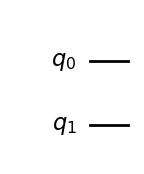

In [ ]:
# f(x) = 0  (constant function)
def oracle_f0(qc, x, y):
    """
    f0(x) = 0  (constant zero)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR 0⟩ = |x⟩|y⟩
    """
    
    # Does nothing because f(x) = 0 -> y XOR 0 = y
    # Return unmodified circuit 
    return qc

# Display the circuit for oracle_f0
# Expected: an empty circuit — no gates are applied
display(oracle_f0(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f1(qc, x, y) - constant one function:**

The following function implements the constant one function ``f(x) = 1`` -> since ``f(x) = 1`` for all x, the oracle transformation becomes:

$$U_{f_1}\,|x\rangle|y\rangle = |x\rangle|y \oplus 1\rangle = |x\rangle|\text{NOT}\,y\rangle$$

XOR-ing with 1 always flips the ancilla Q-bit not matter the value of x. This is emplemetned with a single Pauli-X gate on y, which is the quantum equivalent of a classical NOT gate (flips |0⟩ to |1⟩ and vice versa unconditionally). Unlike ``oracle_f2`` and ``oracle_f3`` (covered later in this problem), there is no dependency on x at all - the X gate is applied directly to y with no control Q-bit. This makes oracle_f1 the simplest non-trivial oracle: one gate, no conditioning, ancilla always flips. 

* **Step 1:** Receive the quantum circuit qc and qubit indices x and y.
* **Step 2:** Apply an X gate to y to implement y ⊕ 1 = NOT y.
* **Step 3:** Return the modified circuit.

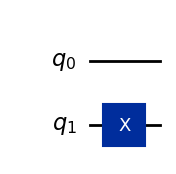

In [ ]:
def oracle_f1(qc, x, y):
    """
    f1(x) = 1  (constant one)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR 1⟩ = |x⟩|NOT y⟩
    """
    
    # f(x) = 1 for all x, so y XOR f(x) = y XOR 1 = NOT y.
    # X gate (Pauli-X) is the quantum NOT — flips |0⟩↔|1⟩ unconditionally.
    # No dependency on x: the flip happens regardless of the input qubit's state.
    qc.x(y)
    # Return the resulting qc
    return qc

# Display the circuit for oracle_f1
# Expected: a single X gate on the ancilla qubit y — no dependency on x
display(oracle_f1(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f2(qc, x, y) - identity / balanced function:**

``oracle_f2`` implements the identity function ``f(x) = x``. Since ``f(x) = x``, the oracle transformation becomes:

$$U_{f_2}\,|x\rangle|y\rangle = |x\rangle|y \oplus x\rangle$$
 
The ancilla qubit y is flipped if and only if x = 1, and left unchanged if x = 0. This is implemented with a single CNOT gate, where x is the control qubit and y is the target. The CNOT is the natural quantum gate for this operation: it applies a Pauli-X to the target only when the control is |1⟩, which is exactly the behaviour y ⊕ x requires. Unlike ``oracle_f1`` which flips y unconditionally, and ``oracle_f3`` which flips y when x = 0, ``oracle_f2`` flips y when x = 1 — making it the most direct mapping from a classical Boolean function to a quantum gate, as the function value and the control condition are one and the same.

* **Step 1:** Receive the quantum circuit qc and qubit indices x (input/control) and y (ancilla/target).
* **Step 2:** Apply a CNOT gate with x as the control and y as the target to implement y⊕x.
* **Step 3:** Return the modified circuit.

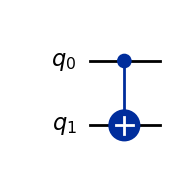

In [29]:
def oracle_f2(qc, x, y):
    """
    f2(x) = x  (identity / balanced)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR x⟩
    """
    
    # f(x) = x, so y XOR f(x) = y XOR x — flip y iff x is |1⟩.
    # CNOT (controlled-X): x is the control qubit, y is the target.
    # |0⟩|y⟩ → |0⟩|y⟩  (x=0: no flip)
    # |1⟩|y⟩ → |1⟩|NOT y⟩  (x=1: flip y)
    qc.cx(x, y)

    # Return the resulting qc
    return qc

# Display the circuit for oracle_f2
# Expected: a single CNOT gate with x as control and y as target
display(oracle_f2(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f3(qc, x, y) - negation / balanced function:**

``oracle_f3`` implements the negation function ``f(x) = NOT x``. Since ``f(x) = NOT x``, the oracle transformation becomes:

$$U_{f_3}\,|x\rangle|y\rangle = |x\rangle|y \oplus 1 \oplus x\rangle$$

Since x⊕1=¬x, this simplifies to:

$$U_{f_3}\,|x\rangle|y\rangle = |x\rangle|y \oplus \neg x\rangle$$

The ancilla qubit y is first entangled with the input qubit x using a CNOT gate, which flips y when x=1. An X gate is then applied to y, which flips the result unconditionally. Together, these operations implement the required conditional behaviour for the negation function.

* **Step 1:** Receive the quantum circuit qc and qubit indices x (input) and y (ancilla/target).
* **Step 2:** Apply a CNOT gate with x as control and y as target to compute y⊕x.
* **Step 3:** Apply an X gate to y, producing y⊕x⊕1=y⊕¬x.
* **Step 4:** Return the modified circuit.

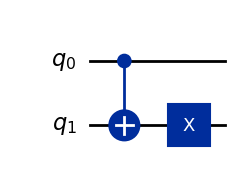

In [ ]:
def oracle_f3(qc, x, y):
    """
    f(x) = NOT x implemented using CX then X on y.

    Oracle action:
    |x⟩|y⟩ → |x⟩|y ⊕ x ⊕ 1⟩ → |x⟩|y ⊕ ¬x⟩
    """

    # Step 1: Entangle input with output (standard CNOT)
    qc.cx(x, y)

    # Step 2: Flip output to complete ¬x transformation
    qc.x(y)

    # Step 3: Return circuit
    return qc

# Display the circuit for oracle_f3
# Expected: X gate on x, then CNOT(x → y), then X gate on x to restore x
display(oracle_f3(QuantumCircuit(2), 0, 1).draw('mpl'))

### **Problem 3 Testing**

**Main function which automates tests**

In [33]:
def run_oracle(oracle_fn, x_init: int, y_init: int) -> tuple[int, int]:
    """
    Build a two-qubit circuit, initialise |x⟩|y⟩ to the given basis state,
    apply the oracle, measure both qubits, and return (x_measured, y_measured).
 
    Because the inputs are computational basis states (no superposition), the
    result is deterministic — 1024 shots all produce the same bitstring.
 
    Qiskit's measurement string is ordered q1q0 (most-significant bit first),
    so we reverse it before extracting individual qubit values.
    """
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)
 
    # Initialise input qubit x (qr[0]) to |x_init⟩
    if x_init == 1:
        qc.x(qr[0])
 
    # Initialise ancilla qubit y (qr[1]) to |y_init⟩
    if y_init == 1:
        qc.x(qr[1])
 
    # Apply the oracle under test
    oracle_fn(qc, qr[0], qr[1])
 
    # Measure both qubits
    qc.measure(qr, cr)
 
    # Simulate and extract the single deterministic outcome
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()
 
    # counts keys are bitstrings ordered "c1c0"; reverse to get [c0, c1]
    bitstring = max(counts, key=counts.get)[::-1]
    x_out = int(bitstring[0])   # qubit 0 — the input qubit x
    y_out = int(bitstring[1])   # qubit 1 — the ancilla qubit y
 
    return x_out, y_out

#### **oracle_f0 Function Tests:**

In [34]:
# Tests oracle_f0 with 00 input 
def test_f0_input_00():
    # f0 is the constant zero function, so f0(0) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # Since f0 never depends on x, x is also unchanged — both qubits stay 0.
    x_out, y_out = run_oracle(oracle_f0, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 0  # |0⟩|0⟩ → |0⟩|0⟩  (0 XOR 0 = 0)
    print(f"f0 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 01 input 
def test_f0_input_01():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # This confirms that even when x = 1, f0 still returns 0 — it is constant.
    x_out, y_out = run_oracle(oracle_f0, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 1  # |0⟩|1⟩ → |0⟩|1⟩  (1 XOR 0 = 1)
    print(f"f0 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 10 input 
def test_f0_input_10():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # This confirms that even when x = 1, f0 still returns 0 — it is constant.
    x_out, y_out = run_oracle(oracle_f0, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 0  # |1⟩|0⟩ → |1⟩|0⟩  (0 XOR 0 = 0)
    print(f"f0 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 11 input 
def test_f0_input_11():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 1 XOR 0 = 1, so y remains 1.
    # Together, all four tests confirm that oracle_f0 leaves every input
    # unchanged — consistent with XOR-ing by 0 being the identity operation.
    x_out, y_out = run_oracle(oracle_f0, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 1  # |1⟩|1⟩ → |1⟩|1⟩  (1 XOR 0 = 1)
    print(f"f0 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f1 Function Tests:**

In [35]:
# Tests oracle_f1 with 00 input 
def test_f1_input_00():
    # f1 is the constant one function, so f1(0) = 1.
    # The oracle computes y XOR f1(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # x is unaffected — the X gate in oracle_f1 acts only on the ancilla qubit.
    x_out, y_out = run_oracle(oracle_f1, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 1  # |0⟩|0⟩ → |0⟩|1⟩  (0 XOR 1 = 1)
    print(f"f1 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f1 with 01 input 
def test_f1_input_01():
    # f1 is the constant one function, so f1(0) = 1.
    # The oracle computes y XOR f1(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # This shows the X gate always toggles y — when y starts as 1, it becomes 0.
    x_out, y_out = run_oracle(oracle_f1, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 0  # |0⟩|1⟩ → |0⟩|0⟩  (1 XOR 1 = 0)
    print(f"f1 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f1 with 10 input 
def test_f1_input_10():
    # f1 is the constant one function, so f1(1) = 1.
    # The oracle computes y XOR f1(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Critically, x = 1 here — confirming the flip still occurs regardless of x.
    x_out, y_out = run_oracle(oracle_f1, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 1  # |1⟩|0⟩ → |1⟩|1⟩  (0 XOR 1 = 1)
    print(f"f1 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f1 with 11 input 
def test_f1_input_11():
    # f1 is the constant one function, so f1(1) = 1.
    # The oracle computes y XOR f1(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # All four tests together confirm that oracle_f1 always flips y regardless
    # of x — consistent with the unconditional X gate used in its implementation.
    x_out, y_out = run_oracle(oracle_f1, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 0  # |1⟩|1⟩ → |1⟩|0⟩  (1 XOR 1 = 0)
    print(f"f1 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f2 Function Tests:**

In [13]:
# Tests oracle_f2 with 00 input
def test_f2_input_00():
    # f2 is the identity function, so f2(0) = 0.
    # The oracle computes y XOR f2(x) = 0 XOR 0 = 0, so y remains 0.
    # Since x = 0, the CNOT in oracle_f2 does not fire — its control qubit is 0,
    # so the target qubit y is left completely unchanged. Neither qubit changes.
    x_out, y_out = run_oracle(oracle_f2, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 0  # |0⟩|0⟩ → |0⟩|0⟩  (0 XOR 0 = 0)
    print(f"f2 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f2 with 01 input
def test_f2_input_01():
    # f2 is the identity function, so f2(0) = 0.
    # The oracle computes y XOR f2(x) = 1 XOR 0 = 1, so y remains 1.
    # Again x = 0, so the CNOT does not fire — y is left at its initial value of 1.
    # This confirms that when x = 0, oracle_f2 behaves as the identity regardless
    # of y's starting value, consistent with f2(0) = 0 contributing nothing to XOR.
    x_out, y_out = run_oracle(oracle_f2, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 1  # |0⟩|1⟩ → |0⟩|1⟩  (1 XOR 0 = 1)
    print(f"f2 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f2 with 10 input
def test_f2_input_10():
    # f2 is the identity function, so f2(1) = 1.
    # The oracle computes y XOR f2(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Since x = 1, the CNOT fires — its control qubit is 1, so the target qubit
    # y is flipped. This is the key case that distinguishes oracle_f2 from oracle_f0:
    # the oracle only modifies y when x = 1, directly encoding the identity function.
    x_out, y_out = run_oracle(oracle_f2, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 1  # |1⟩|0⟩ → |1⟩|1⟩  (0 XOR 1 = 1)
    print(f"f2 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f2 with 11 input
def test_f2_input_11():
    # f2 is the identity function, so f2(1) = 1.
    # The oracle computes y XOR f2(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # x = 1 again, so the CNOT fires and toggles y — when y starts as 1 it becomes 0.
    # All four tests together confirm that oracle_f2 flips y if and only if x = 1,
    # which is exactly the behaviour of a CNOT gate and the identity function f2(x) = x.
    x_out, y_out = run_oracle(oracle_f2, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 0  # |1⟩|1⟩ → |1⟩|0⟩  (1 XOR 1 = 0)
    print(f"f2 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f3 Function Tests:**

In [36]:
# Tests oracle_f3 with 00 input
def test_f3_input_00():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Since x = 0, the first X gate in oracle_f3 temporarily flips x to 1,
    # causing the CNOT to fire and flip y. The second X gate then restores x to 0.
    # This is the anti-controlled NOT in action — the flip occurs because x = 0,
    # which is the opposite control condition to oracle_f2's CNOT.
    x_out, y_out = run_oracle(oracle_f3, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 1  # |0⟩|0⟩ → |0⟩|1⟩  (0 XOR NOT 0 = 1)
    print(f"f3 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f3 with 01 input
def test_f3_input_01():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # Again x = 0, so the flanking X gates cause the CNOT to fire, toggling y.
    # When y starts as 1 it becomes 0 — confirming the flip always occurs when
    # x = 0, regardless of y's initial value.
    x_out, y_out = run_oracle(oracle_f3, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 0  # |0⟩|1⟩ → |0⟩|0⟩  (1 XOR NOT 0 = 0)
    print(f"f3 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f3 with 10 input
def test_f3_input_10():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # Again x = 0, so the flanking X gates cause the CNOT to fire, toggling y.
    # When y starts as 1 it becomes 0 — confirming the flip always occurs when
    # x = 0, regardless of y's initial value.
    x_out, y_out = run_oracle(oracle_f3, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 0  # |1⟩|0⟩ → |1⟩|0⟩  (0 XOR NOT 1 = 0)
    print(f"f3 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f3 with 11 input
def test_f3_input_11():
    # f3 is the negation function, so f3(1) = NOT 1 = 0.
    # The oracle computes y XOR f3(x) = 0 XOR 0 = 0, so y remains unchanged.
    # Since x = 1, the first X gate flips x to 0, so the CNOT does not fire —
    # its control is now 0 after the flip. The second X gate restores x to 1.
    # This is the key case that distinguishes oracle_f3 from oracle_f1: when
    # x = 1, no flip occurs, because f3(1) = 0 contributes nothing to the XOR.
    x_out, y_out = run_oracle(oracle_f3, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 1  # |1⟩|1⟩ → |1⟩|1⟩  (1 XOR NOT 1 = 1)
    print(f"f3 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### Run the tests from main

In [37]:
# Main function to run the tests for the oracles
if __name__ == "__main__":
    # Run tests for oracle_f0
    print("oracle_f0 tests:")
    test_f0_input_00()
    test_f0_input_01()
    test_f0_input_10()
    test_f0_input_11()
    
    # Run tests for oracle_f1
    print("\noracle_f1 tests:")
    test_f1_input_00()
    test_f1_input_01()
    test_f1_input_10()
    test_f1_input_11()

    # Run tests for oracle_f2
    print("\noracle_f2 tests:")
    test_f2_input_00()
    test_f2_input_01()
    test_f2_input_10()
    test_f2_input_11()
    
    # Run tests for oracle_f3
    print("\noracle_f3 tests:")
    test_f3_input_00()
    test_f3_input_01()
    test_f3_input_10()
    test_f3_input_11()

oracle_f0 tests:
f0 |0⟩|0⟩ → |0⟩|0⟩ ✓
f0 |0⟩|1⟩ → |0⟩|1⟩ ✓
f0 |1⟩|0⟩ → |1⟩|0⟩ ✓
f0 |1⟩|1⟩ → |1⟩|1⟩ ✓

oracle_f1 tests:
f1 |0⟩|0⟩ → |0⟩|1⟩ ✓
f1 |0⟩|1⟩ → |0⟩|0⟩ ✓
f1 |1⟩|0⟩ → |1⟩|1⟩ ✓
f1 |1⟩|1⟩ → |1⟩|0⟩ ✓

oracle_f2 tests:
f2 |0⟩|0⟩ → |0⟩|0⟩ ✓
f2 |0⟩|1⟩ → |0⟩|1⟩ ✓
f2 |1⟩|0⟩ → |1⟩|1⟩ ✓
f2 |1⟩|1⟩ → |1⟩|0⟩ ✓

oracle_f3 tests:
f3 |0⟩|0⟩ → |0⟩|1⟩ ✓
f3 |0⟩|1⟩ → |0⟩|0⟩ ✓
f3 |1⟩|0⟩ → |1⟩|0⟩ ✓
f3 |1⟩|1⟩ → |1⟩|1⟩ ✓


## **Problem 4: Deutsch's Algorithm with Qiskit**

### **Introduction**

Problem 4 builds directly on the four oracles implemented in Problem 3. Deutsch's algorithm is the simplest quantum algorithm that demonstrates a provable speedup over any classical approach — it determines whether a Boolean function f: {0,1} → {0,1} is constant (f(0) = f(1)) or balanced (f(0) ≠ f(1)) using only a single query to the oracle. Classically this is impossible in one query, since you must evaluate both f(0) and f(1) separately. The quantum circuit achieves this by placing the input qubit into superposition with a Hadamard gate, querying the oracle once across both inputs simultaneously, then applying a second Hadamard to convert the phase difference introduced by the oracle into a measurable amplitude difference. If the function is constant both paths interfere constructively and the input qubit measures |0⟩. If balanced they interfere destructively and it measures |1⟩ — a single measurement reveals the global property.

### **Function build_deutsch_circuit(oracle_fn):**

The build_deutsch_circuit function constructs the quantum circuit for Deutsch's algorithm for a given oracle. The circuit operates on two qubits: q0 is the input qubit initialised to |0⟩, and q1 is the ancilla qubit initialised to |1⟩ via an X gate. The ancilla must start as |1⟩ so that after its Hadamard gate it enters the |−⟩ = (|0⟩ − |1⟩)/√2 state — this is a prerequisite for phase kickback to work. Without it, the oracle would XOR into |0⟩ and no phase would be imprinted on the input qubit. After initialisation, Hadamard gates are applied to both qubits: q0 enters the uniform superposition |+⟩ = (|0⟩ + |1⟩)/√2, encoding both possible inputs simultaneously, and q1 becomes |−⟩ as described. The oracle is then applied to this two-qubit state. With q1 in |−⟩, the phase kickback mechanism causes the oracle to imprint a phase of (−1)^f(x) onto q0 rather than modifying the ancilla — the transformation |x⟩|−⟩ → (−1)^f(x)|x⟩|−⟩ leaves q1 unchanged and encodes f's output entirely as a phase on q0. Finally, a second Hadamard is applied to q0 alone to interfere the two phase-encoded amplitudes: if f is constant both phases are equal and interfere constructively, collapsing q0 to |0⟩; if f is balanced the phases are opposite and interfere destructively, collapsing q0 to |1⟩. Measuring q0 then directly reveals the answer.

In [16]:
def build_deutsch_circuit(oracle_fn):
    """
    Construct the Deutsch algorithm circuit for a given oracle.
 
    The circuit uses two qubits:
      q0 — input qubit (x): initialised to |0⟩
      q1 — ancilla qubit (y): initialised to |1⟩ via an X gate
 
    Returns the full circuit before measurement so the state can be inspected.
    """

    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(qr, cr)

    # Initialise ancilla to |1⟩ — required for phase kickback to work
    # Without this, the oracle XORs into |0⟩ and no phase is imprinted
    qc.x(qr[1])
 
    # Apply Hadamard to both qubits
    # q0: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2  — superposition over both inputs
    qc.h(qr[0])
    # q1: |1⟩ → |−⟩ = (|0⟩ − |1⟩)/√2  — the phase kickback ancilla state
    qc.h(qr[1])
 
    # visually separate initialisation from oracle
    qc.barrier()  
 
    # Apply the oracle. With q1 in |−⟩, the oracle imprints a phase:
    #   |x⟩|−⟩ → (−1)^f(x) |x⟩|−⟩
    # The ancilla is unchanged; the phase is now on q0.
    oracle_fn(qc, qr[0], qr[1])
 
    # visually separate oracle from interference step
    qc.barrier() 
 
    # Apply Hadamard to q0 only to interfere the two phase-encoded amplitudes
    # Constant f:  phases equal    → constructive interference → |0⟩
    # Balanced f:  phases opposite → destructive interference  → |1⟩
    qc.h(qr[0])
 
    # Measure only q0 — it encodes the constant/balanced answer
    qc.measure(qr[0], cr[0])
 
    return qc

### **Function run_deutsch(oracle_fn):**

The run_deutsch function executes the Deutsch circuit for a given oracle and maps the measurement outcome to a classification. It calls build_deutsch_circuit to construct the circuit, then simulates it using Qiskit's AerSimulator over 1024 shots. Because the result is deterministic — the interference pattern always collapses q0 to either |0⟩ or |1⟩ with certainty — all 1024 shots produce the same bitstring, and the shot count affects only statistical confidence rather than correctness. The dominant measurement outcome is extracted from the counts and mapped directly to a classification: a measured bit of '0' means the function is constant, since constructive interference concentrated all amplitude on |0⟩, and a measured bit of '1' means the function is balanced, since destructive interference redirected all amplitude away from |0⟩. The function returns the classification, the raw counts, and the circuit itself so the result can be inspected and verified by the caller.

In [17]:
def run_deutsch(oracle_fn): 
    """
    Run the Deutsch circuit for the given oracle and return the classification
    ('CONSTANT' or 'BALANCED') along with the raw measurement counts.
    """

    # Create quantum circuit 
    qc = build_deutsch_circuit(oracle_fn)

    # Simulate with 1024 shots. The result is deterministic — all shots produce
    # the same bit — so shot count only affects statistical confidence.
    counts = AerSimulator().run(qc, shots=1024).result().get_counts()
 
    # q0 = '0' → constant, q0 = '1' → balanced
    measured_bit = max(counts, key=counts.get)
    classification = "CONSTANT" if measured_bit == '0' else "BALANCED"
 
    return classification, counts, qc
 

### **Testing**

In [18]:
# ── Single oracle query ───────────────────────────────────────────────────────
# The defining property of Deutsch's algorithm is that it queries the oracle
# exactly once. These tests verify this by inspecting the circuit directly.

def test_circuit_queries_oracle_exactly_once():
    # The Deutsch circuit must contain exactly one barrier-separated oracle
    # section — confirming only a single query is made to determine the result.
    # More than one oracle call would defeat the purpose of the algorithm.
    qc = build_deutsch_circuit(oracle_f0)
    # Count barriers — the circuit has two barriers (before and after oracle),
    # confirming the oracle is applied exactly once between them
    barrier_count = sum(1 for instr in qc.data if instr.operation.name == 'barrier')
    assert barrier_count == 2  # one before oracle, one after — oracle called once
    print(f"Circuit contains {barrier_count} barriers → oracle queried exactly once ✓")

def test_circuit_has_two_hadamards_on_input_qubit():
    # Deutsch's algorithm requires exactly two Hadamard gates on the input qubit
    # q0 — one to create superposition before the oracle, and one to perform
    # interference after. These two gates are what enable a single query to suffice.
    qc = build_deutsch_circuit(oracle_f0)
    h_on_q0 = [instr for instr in qc.data
                if instr.operation.name == 'h'
                and instr.qubits[0] == qc.qregs[0][0]]
    assert len(h_on_q0) == 2  # one for superposition, one for interference
    print(f"q0 has {len(h_on_q0)} Hadamard gates → superposition and interference confirmed ✓")

In [19]:
if __name__ == "__main__":
    test_circuit_queries_oracle_exactly_once()
    test_circuit_has_two_hadamards_on_input_qubit()
    print("\nAll tests passed!")

Circuit contains 2 barriers → oracle queried exactly once ✓
q0 has 2 Hadamard gates → superposition and interference confirmed ✓

All tests passed!


In [20]:
if __name__ == "__main__":
 
    # Each entry is (display name, oracle function, expected classification).
    # The expected value is used to verify the algorithm gives the correct answer.
    oracles = [
        ("f0: f(x) = 0",   oracle_f0, "CONSTANT"),
        ("f1: f(x) = 1",   oracle_f1, "CONSTANT"),
        ("f2: f(x) = x",   oracle_f2, "BALANCED"),
        ("f3: f(x) = ¬x",  oracle_f3, "BALANCED"),
    ]
 
    print("=" * 60)
    print("  Problem 4: Deutsch's Algorithm")
    print("=" * 60)
 
    # Run the Deutsch circuit once per oracle and print the outcome.
    # Each oracle only needs a single query to classify — no repetition needed.
    for name, oracle_fn, expected in oracles:
        classification, counts, qc = run_deutsch(oracle_fn)

        # Compare against the known answer to confirm the algorithm is correct
        correct = classification == expected
 
        print(f"\n  Oracle : {name}")
        print(f"  Circuit:\n{qc.draw('text', fold=-1)}")
        print(f"  Counts : {counts}")
        print(f"  Result : {classification} ({'✓ correct' if correct else '✗ wrong'})")
 
    print("\n" + "=" * 60)
    print("  How the interference works")
    print("=" * 60)
    print("""
  After the Hadamard gates, the two-qubit state is:
 
    (|0⟩ + |1⟩)/√2  ⊗  (|0⟩ − |1⟩)/√2
 
  The oracle maps |x⟩|−⟩ → (−1)^f(x)|x⟩|−⟩, so q0 becomes:
 
    (−1)^f(0)|0⟩ + (−1)^f(1)|1⟩  (up to normalisation)
 
  The final Hadamard on q0 then gives:
 
    Constant f — f(0)=f(1): phases equal, interference is constructive
      → amplitude concentrates on |0⟩ → measures 0
 
    Balanced f — f(0)≠f(1): phases opposite, interference is destructive
      → amplitude concentrates on |1⟩ → measures 1
 
  One oracle call encodes both f(0) and f(1) simultaneously through
  superposition, and interference converts the phase relationship into
  a directly measurable bit.
""")

  Problem 4: Deutsch's Algorithm

  Oracle : f0: f(x) = 0
  Circuit:
     ┌───┐      ░  ░ ┌───┐┌─┐
q_0: ┤ H ├──────░──░─┤ H ├┤M├
     ├───┤┌───┐ ░  ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░──░───────╫─
     └───┘└───┘ ░  ░       ║ 
c: 1/══════════════════════╩═
                           0 
  Counts : {'0': 1024}
  Result : CONSTANT (✓ correct)

  Oracle : f1: f(x) = 1
  Circuit:
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───────░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌───┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 
  Counts : {'0': 1024}
  Result : CONSTANT (✓ correct)

  Oracle : f2: f(x) = x
  Circuit:
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■───░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 
  Counts : {'1': 1024}
  Result : BALANCED (✓ cor

### **Problem 4 Testing**

## **Problem 5: Scaling to the Deutsch–Jozsa Algorithm**

**Brief:** The Deutsch–Jozsa algorithm generalizes Deutsch's approach to functions with several input bits. Use Qiskit to create a quantum circuit that can handle the four-bit functions generated in Problem 1. Explain how the classical function is encoded as a quantum oracle, and demonstrate the use of your circuit on both of the constant functions and any two balanced functions of your choosing. Show that the circuit correctly identifies the type of each function.

**Introduction:** Problem 5 generalises Deutsch's algorithm from a single input bit to multiple input bits. The Deutsch–Jozsa algorithm determines whether a function f: {0,1}ⁿ → {0,1} is constant or balanced in a single oracle query, regardless of how many input bits n there are. Classically, in the worst case, you would need 2ⁿ⁻¹ + 1 evaluations to be certain. Here n = 4, as the functions were generated in Problem 1. The circuit structure is a direct generalisation of Deutsch's: n input qubits are placed into superposition, the oracle is queried once, and a final layer of Hadamard gates produces an interference pattern that is all |0⟩s if and only if the function is constant. The key challenge in this problem is encoding the classical four-bit function as a quantum oracle — a phase oracle that maps |x⟩ → (−1)^f(x)|x⟩ via the same phase kickback mechanism used in Problem 3.

### **build_oracle(classical_fn) function:**

The build_oracle function converts a classical 4-input Boolean function — as generated by Problem 1 — into a quantum oracle circuit. The oracle iterates over all 16 possible inputs and for each input where f(x) = True, constructs a gate sequence that flips the ancilla qubit q4 if and only if the input register holds exactly that input. This is achieved using the same X-MCX-X pattern introduced in oracle_f3 in Problem 3, scaled up to 4 control qubits. For each target input, X gates are applied to any qubits that are False in that input, temporarily flipping them to True so that the multi-controlled X gate (MCX) fires on the correct computational basis state. The MCX then flips the ancilla, encoding y ⊕ f(x) on q4. Finally, the X gates are reapplied to restore the input qubits to their original state, preserving the unitary requirement that the input register is left unchanged. Inputs where f(x) = False require no gates at all, since y ⊕ 0 = y is the identity.

In [21]:
"""
Problem 5: Scaling to the Deutsch-Jozsa Algorithm (4-bit)
==========================================================
Generalises Deutsch's algorithm (Problem 4) to f: {0,1}^4 → {0,1}.

Builds directly on:
  - Problem 1: random_constant_balanced() generates the functions under test
  - Problem 2: determine_constant_balanced() provides the classical answer to
               verify against and illustrate the classical vs quantum cost
  - Problem 3: same phase kickback oracle construction, scaled to 4 input qubits
  - Problem 4: same H-oracle-H circuit structure, scaled to 4 input qubits

The circuit measures all zeros on q0-q3 if and only if the function is constant.
"""

# ──────────────────────────────────────────────────────────────────────────────
# Step 1 — Encode the classical function as a quantum oracle
# ──────────────────────────────────────────────────────────────────────────────

# All 16 possible 4-bit inputs — used to iterate over the function's truth table
ALL_INPUTS = list(product([False, True], repeat=4))

def build_oracle(classical_fn) -> QuantumCircuit:
    """
    Convert a classical 4-input Boolean function (from Problem 1) into a
    quantum oracle using the same phase kickback pattern as Problem 3.

    For each input x where f(x) = True, a multi-controlled X gate (MCX) is
    applied to the ancilla qubit, conditioned on the input register holding x.
    X gates flanking the MCX invert any False-bits in x so the MCX fires on
    exactly the right computational basis state — the same X-CNOT-X pattern
    used in oracle_f3 in Problem 3, generalised to 4 control qubits.
    """
    n = 4
    qr = QuantumRegister(n + 1, 'q')  # q0-q3: input qubits, q4: ancilla
    qc = QuantumCircuit(qr)

    for x in ALL_INPUTS:
        if classical_fn(*x):  # only act on inputs where f(x) = True
            # Flip qubits that are False in this input pattern so the MCX
            # fires when the register holds exactly x
            for i, bit in enumerate(x):
                if not bit:
                    qc.x(qr[i])

            # MCX flips ancilla q4 iff q0-q3 match x — encodes y XOR f(x)
            qc.mcx(list(range(n)), n)

            # Restore the input qubits to their original state
            for i, bit in enumerate(x):
                if not bit:
                    qc.x(qr[i])

    return qc

### **build_dj_circuit(classical_fn) function:**

The build_dj_circuit function constructs the full Deutsch-Jozsa circuit for a given 4-input Boolean function — a direct generalisation of the Deutsch circuit from Problem 4, scaled from 1 input qubit to 4. The circuit follows the same three-stage structure: first, all qubits are initialised and Hadamarded into superposition; second, the oracle is applied; third, a final layer of Hadamard gates produces an interference pattern that encodes the answer. The ancilla qubit q4 is initialised to |1⟩ before the Hadamard layer, placing it in the |−⟩ state required for phase kickback — identical to the setup in Problem 4. After the oracle imprints a phase of (−1)^f(x) on each input basis state, the Hadamard gates on q0–q3 interfere those phases: for a constant function all phases are equal and interfere constructively, concentrating the entire probability amplitude on the all-zeros state |0000⟩; for a balanced function the phases cancel at |0000⟩ and the measurement always produces a non-zero bitstring. Only the four input qubits are measured — the ancilla is discarded — and a result of 0000 identifies the function as constant while any other result identifies it as balanced.

In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 2 — Build the Deutsch-Jozsa circuit
# ──────────────────────────────────────────────────────────────────────────────

def build_dj_circuit(classical_fn) -> QuantumCircuit:
    """
    Build the full Deutsch-Jozsa circuit — a direct generalisation of the
    Deutsch circuit from Problem 4, scaled from 1 to 4 input qubits.

    Problem 4 circuit:    |0⟩ ──H──[oracle]──H── measure
    This circuit:    |0⟩⊗4 ──H⊗4──[oracle]──H⊗4── measure (on q0-q3 only)

    The ancilla qubit q4 is initialised to |1⟩ and Hadamarded into |−⟩ for
    phase kickback, exactly as in Problem 4.
    """
    n = 4
    qr = QuantumRegister(n + 1, 'q')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr, cr)

    # Initialise ancilla to |1⟩ — same as Problem 4, needed for phase kickback
    qc.x(qr[n])

    # Hadamard on all qubits: input qubits enter uniform superposition,
    # ancilla becomes |−⟩ = (|0⟩ − |1⟩)/√2
    qc.h(qr[:])

    qc.barrier()

    # Apply oracle — imprints (−1)^f(x) phase onto the input register,
    # using the same phase kickback mechanism as Problem 3
    oracle = build_oracle(classical_fn)
    qc.compose(oracle, inplace=True)

    qc.barrier()

    # Hadamard on input qubits only — interferes the phase-encoded amplitudes.
    # Constant f → all phases equal → constructive interference → |0000⟩
    # Balanced f → phases cancel at |0000⟩ → non-zero result
    qc.h(qr[:n])

    # Measure input qubits only — ancilla is discarded
    qc.measure(qr[:n], cr)

    return qc


### **Runner function - run_dj(classical_fn):** 

The run_dj function executes the Deutsch-Jozsa circuit for a given 4-input Boolean function and returns the classification. It calls build_dj_circuit to construct the circuit, simulates it over 1024 shots, and maps the dominant measurement outcome to either "constant" or "balanced". The result is deterministic — all 1024 shots always agree — so the classification is read directly from whichever bitstring dominates the counts. A measurement of '0000' on q0–q3 indicates a constant function, since constructive interference concentrated all amplitude on the all-zeros state. Any other outcome indicates a balanced function, since destructive interference prevented any amplitude from reaching '0000'.

In [23]:
def run_dj(classical_fn) -> tuple[str, dict, QuantumCircuit]:
    """
    Run the Deutsch-Jozsa circuit for a function generated by Problem 1.
    Returns the quantum classification, raw counts, and the circuit.
 
    Measurement of '0000' → constant (constructive interference)
    Any other outcome    → balanced (destructive interference at |0000⟩)
    """
    
    qc = build_dj_circuit(classical_fn)
 
    # Result is deterministic — all 1024 shots produce the same bitstring
    counts = AerSimulator().run(qc, shots=1024).result().get_counts()
    outcome = max(counts, key=counts.get)
 
    classification = "constant" if all(b == '0' for b in outcome) else "balanced"
 
    return classification, counts, qc

### **Testing**

In [24]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 4 — Demonstrate on two constant and two balanced functions
# ──────────────────────────────────────────────────────────────────────────────
 
if __name__ == "__main__":
 
    print("=" * 65)
    print("  Problem 5: Deutsch-Jozsa Algorithm (4-bit)")
    print("=" * 65)
 
    # Use Problem 1 to generate two constant and two balanced functions,
    # re-sampling until we have the right mix for demonstration
    constant_fns = []
    balanced_fns = []
 
    while len(constant_fns) < 2 or len(balanced_fns) < 2:
        f = random_constant_balanced()
        # Use Problem 2 to label the function so we can sort it
        label = determine_constant_balanced(f)
        if label == "constant" and len(constant_fns) < 2:
            constant_fns.append(f)
        elif label == "balanced" and len(balanced_fns) < 2:
            balanced_fns.append(f)
 
    functions_to_test = (
        [(f, "constant") for f in constant_fns] +
        [(f, "balanced") for f in balanced_fns]
    )
 
    for i, (fn, expected) in enumerate(functions_to_test, 1):
 
        # Classical answer from Problem 2 — requires up to 16 calls to f
        classical_result = determine_constant_balanced(fn)
 
        # Quantum answer from Problem 5 — requires exactly 1 oracle query
        quantum_result, counts, qc = run_dj(fn)
 
        # Both should agree — if not, something is wrong with the oracle encoding
        agree = classical_result == quantum_result
        correct = quantum_result == expected
 
        print(f"\n  Function {i} (expected: {expected})")
        print(f"  Classical result (Problem 2) : {classical_result}  [up to 16 calls]")
        print(f"  Quantum result   (Problem 5) : {quantum_result}  [1 oracle query]")
        print(f"  Measurement counts           : {counts}")
        print(f"  Correct? {'✓ yes' if correct else '✗ no'}  |  Classical and quantum agree? {'✓ yes' if agree else '✗ no'}")
 
    print("\n" + "=" * 65)
    print("  Classical vs Quantum cost")
    print("=" * 65)
    print("""
  Problem 2 (classical): must evaluate f on every input to be certain.
    Worst case: 2^(n-1) + 1 = 9 evaluations for n=4.
    This implementation always calls f all 16 times.
 
  Problem 5 (quantum): one oracle query regardless of n.
    The uniform superposition feeds all 16 inputs simultaneously,
    and interference on the output reveals the global property
    without ever evaluating individual inputs.
 
  Speedup: exponential — O(1) queries vs O(2^n) classical.
""")

  Problem 5: Deutsch-Jozsa Algorithm (4-bit)

  Function 1 (expected: constant)
  Classical result (Problem 2) : constant  [up to 16 calls]
  Quantum result   (Problem 5) : constant  [1 oracle query]
  Measurement counts           : {'0000': 1024}
  Correct? ✓ yes  |  Classical and quantum agree? ✓ yes

  Function 2 (expected: constant)
  Classical result (Problem 2) : constant  [up to 16 calls]
  Quantum result   (Problem 5) : constant  [1 oracle query]
  Measurement counts           : {'0000': 1024}
  Correct? ✓ yes  |  Classical and quantum agree? ✓ yes

  Function 3 (expected: balanced)
  Classical result (Problem 2) : balanced  [up to 16 calls]
  Quantum result   (Problem 5) : balanced  [1 oracle query]
  Measurement counts           : {'0010': 72, '1010': 70, '0101': 63, '1110': 51, '0110': 47, '1101': 65, '0001': 83, '1011': 251, '1001': 57, '1000': 265}
  Correct? ✓ yes  |  Classical and quantum agree? ✓ yes

  Function 4 (expected: balanced)
  Classical result (Problem 2) : ba